In [ ]:
!pip install fbprophet

  Using cached fbprophet-0.7.1.tar.gz (64 kB)
  Preparing metadata (setup.py) ... done
  Using cached cmdstanpy-0.9.5-py3-none-any.whl.metadata (2.9 kB)
  Using cached pystan-3.10.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached LunarCalendar-0.0.9-py2.py3-none-any.whl.metadata (6.3 kB)
  Using cached convertdate-2.4.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached setuptools_git-1.2-py2.py3-none-any.whl.metadata (5.8 kB)
  Using cached PyMeeus-0.5.12-py3-none-any.whl
  Using cached ephem-4.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.1 kB)
  Using cached clikit-0.6.2-py2.py3-none-any.whl.metadata (1.6 kB)
  Using cached httpstan-4.13.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.2 kB)
  Using cached pysimdjson-6.0.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.9 kB)
  Using cached crashtest-0.3.1-py3-none-any.whl.metadata (748 bytes)
  Using cached pastel-0.2.1-py2.py3-none-any.whl.metadata (1.9 kB)

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
directory = '/content/'
files = [
    'Jumlah Penumpang Kereta Api, 2014.xlsx',
    'Jumlah Penumpang Kereta Api, 2015.xlsx',
    'Jumlah Penumpang Kereta Api, 2016.xlsx',
    'Jumlah Penumpang Kereta Api, 2017.xlsx',
    'Jumlah Penumpang Kereta Api, 2018.xlsx',
    'Jumlah Penumpang Kereta Api, 2019.xlsx',
    'Jumlah Penumpang Kereta Api, 2020.xlsx',
    'Jumlah Penumpang Kereta Api, 2021.xlsx',
    'Jumlah Penumpang Kereta Api, 2022.xlsx',
    'Jumlah Penumpang Kereta Api, 2023.xlsx',
    'Jumlah Penumpang Kereta Api, 2024.xlsx'
]
combined_data = []

for file in files:
    file_path = os.path.join(directory, file)
    df = pd.read_excel(file_path, sheet_name=0)
    jawa_data = df[df['Kereta Api'] == 'Jawa (Jabodetabek+Non Jabodetabek)']
    year = file.split(', ')[1].split('.')[0]
    jawa_data['Year'] = year
    new_columns = {
        'Unnamed: 1': 'January',
        'Unnamed: 2': 'February',
        'Unnamed: 3': 'March',
        'Unnamed: 4': 'April',
        'Unnamed: 5': 'May',
        'Unnamed: 6': 'June',
        'Unnamed: 7': 'July',
        'Unnamed: 8': 'August',
        'Unnamed: 9': 'September',
        'Unnamed: 10': 'October',
        'Unnamed: 11': 'November',
        'Unnamed: 12': 'December'
    }
    jawa_data = jawa_data.rename(columns=new_columns)

    # Remove Unnamed: 13 if it exists
    if 'Unnamed: 13' in jawa_data.columns:
        jawa_data = jawa_data.drop('Unnamed: 13', axis=1)

    combined_data.append(jawa_data)

final_data = pd.concat(combined_data, ignore_index=True)

<ipython-input-79-5dd61ad574a9>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jawa_data['Year'] = year
<ipython-input-79-5dd61ad574a9>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jawa_data['Year'] = year
<ipython-input-79-5dd61ad574a9>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#retur

In [ ]:
final_data

,Kereta Api,January,February,March,April,May,June,July,August,September,October,November,December,Year
0,Jawa (Jabodetabek+Non Jabodetabek),20698,19628,22427,21502,22547,23415,22125,22763,23219,24503,23986,25791,2014
1,Jawa (Jabodetabek+Non Jabodetabek),24254,22394,26841,26150,27450,27118,27077,27351,27125,28280,27253,29328,2015
2,Jawa (Jabodetabek+Non Jabodetabek),27886,26058,28156,28000,30176,28730,28216,29125,29019,29765,29178,31530,2016
3,Jawa (Jabodetabek+Non Jabodetabek),30359,26837,31612,30934,33157,30181,33669,33255,31921,34498,33798,36140,2017
4,Jawa (Jabodetabek+Non Jabodetabek),34107,30721,35272,35135,34877,32270,36089,34560,33878,35602,34637,37197,2018
5,Jawa (Jabodetabek+Non Jabodetabek),34435,31282,35068,35106,34514,34261,38303,34542,34615,35814,35228,36710,2019
6,Jawa (Jabodetabek+Non Jabodetabek),33472,31679,22949,5813,5476,9272,12205,12679,11295,11768,13523,13262,2020
7,Jawa (Jabodetabek+Non Jabodetabek),11631,11223,13995,14590,14627,14313,5646,6479,9510,13139,15161,17207,2021
8,Jawa (Jabodetabek+Non Jabodetabek),17499,12857,19133,19436,23114,23160,25272,23920,25167,27143,26473,29245,2022
9,Jawa (Jabodetabek+Non Jabodetabek),28435,25744,29249,27731,29886,29579,32372,30742,31067,33108,32424,34500,2023


In [ ]:
month_columns = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
reshaped_data = []

# Loop through the rows (by year) and extract the months and passenger data
for index, row in final_data.iterrows():
    year = row['Year']
    for month, passengers in zip(month_columns, row[month_columns]):
        reshaped_data.append({'month': month, 'year': year, 'jumlah_kereta_api': passengers})

# Convert the reshaped data into a new DataFrame
reshaped_df = pd.DataFrame(reshaped_data)
reshaped_df

,month,year,jumlah_kereta_api
0,January,2014,20698
1,February,2014,19628
2,March,2014,22427
3,April,2014,21502
4,May,2014,22547
...,...,...,...
127,August,2024,35292
128,September,2024,34792
129,October,2024,37233
130,November,2024,34849


In [ ]:
# Membuat kolom 'date' dengan tanggal 01 setiap bulannya
reshaped_df['date'] = pd.to_datetime(reshaped_df['month'] + ' ' + reshaped_df['year'].astype(str))

# Menetapkan tanggal menjadi 1 di setiap bulan (jika tidak sudah otomatis)
reshaped_df['date'] = reshaped_df['date'].apply(lambda x: x.replace(day=1))

reshaped_df['year'] = reshaped_df['year'].astype(int)

train = reshaped_df[reshaped_df['year'] < 2024]['jumlah_kereta_api']
test = reshaped_df[reshaped_df['year'] == 2024]['jumlah_kereta_api']

<ipython-input-82-04fec09bae7c>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  reshaped_df['date'] = pd.to_datetime(reshaped_df['month'] + ' ' + reshaped_df['year'].astype(str))


In [ ]:
reshaped_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   month              132 non-null    object        
 1   year               132 non-null    int64         
 2   jumlah_kereta_api  132 non-null    int64         
 3   date               132 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 4.3+ KB


In [ ]:
train

,jumlah_kereta_api
0,20698
1,19628
2,22427
3,21502
4,22547
...,...
115,30742
116,31067
117,33108
118,32424


In [ ]:
test

,jumlah_kereta_api
120,33590
121,31397
122,32277
123,34241
124,34665
125,34524
126,37422
127,35292
128,34792
129,37233


# ARIMA

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


RMSE: 1868.47
MAE: 1413.43


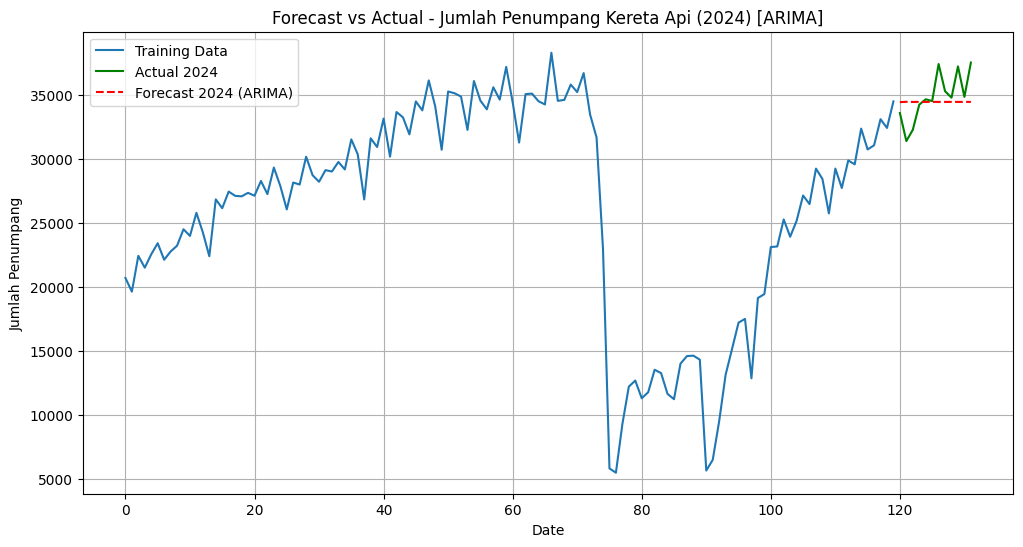

,Actual,Predicted
120,33590,34441.569637
121,31397,34466.625948
122,32277,34455.881214
123,34241,34460.488808
124,34665,34458.512964
125,34524,34459.360252
126,37422,34458.996915
127,35292,34459.152722
128,34792,34459.085909
129,37233,34459.114560


In [ ]:
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=12)

rmse_arima = np.sqrt(mean_squared_error(test, forecast))
mae_arima = mean_absolute_error(test, forecast)

print(f"RMSE: {rmse_arima:.2f}")
print(f"MAE: {mae_arima:.2f}")

result_df = pd.DataFrame({
    'Actual': test.values,
    'Predicted': forecast.values
}, index=test.index)

plt.figure(figsize=(12, 6))
plt.plot(train.index, train.values, label='Training Data')
plt.plot(test.index, test.values, label='Actual 2024', color='green')
plt.plot(forecast.index, forecast.values, label='Forecast 2024 (ARIMA)', color='red', linestyle='--')
plt.title('Forecast vs Actual - Jumlah Penumpang Kereta Api (2024) [ARIMA]')
plt.xlabel('Date')
plt.ylabel('Jumlah Penumpang')
plt.legend()
plt.grid()
plt.show()

result_df

# Seasonal ARIMA

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


RMSE: 1200.87
MAE: 945.54


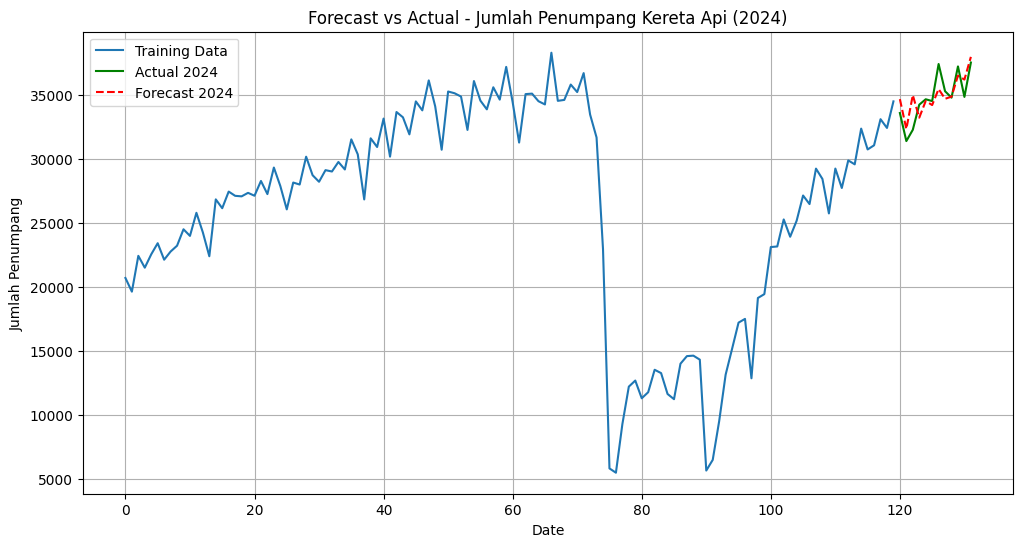

,Actual,Predicted
120,33590,34674.685014
121,31397,32340.233662
122,32277,34990.101188
123,34241,33227.085091
124,34665,34529.395952
125,34524,34212.052546
126,37422,35466.043914
127,35292,34701.113643
128,34792,34870.632558
129,37233,36512.303006


In [ ]:
model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit = model.fit(disp=False)

forecast = model_fit.forecast(steps=12)

rmse_sarima = np.sqrt(mean_squared_error(test, forecast))
mae_sarima = mean_absolute_error(test, forecast)

print(f"RMSE: {rmse_sarima:.2f}")
print(f"MAE: {mae_sarima:.2f}")

result_df = pd.DataFrame({
    'Actual': test.values,
    'Predicted': forecast.values
}, index=test.index)

plt.figure(figsize=(12, 6))
plt.plot(train.index, train.values, label='Training Data')
plt.plot(test.index, test.values, label='Actual 2024', color='green')
plt.plot(forecast.index, forecast.values, label='Forecast 2024', color='red', linestyle='--')
plt.title('Forecast vs Actual - Jumlah Penumpang Kereta Api (2024)')
plt.xlabel('Date')
plt.ylabel('Jumlah Penumpang')
plt.legend()
plt.grid()
plt.show()

result_df

In [ ]:
results_df = pd.DataFrame(columns=['Model', 'RMSE', 'MAE'])
results_df = pd.concat([results_df, pd.DataFrame({'Model': ['ARIMA'], 'RMSE': [round(rmse_arima,2)], 'MAE': [round(mae_arima,2)]})], ignore_index=True)
results_df = pd.concat([results_df, pd.DataFrame({'Model': ['SARIMA'], 'RMSE': [round(rmse_sarima,2)], 'MAE': [round(mae_sarima,2)]})], ignore_index=True)

results_df

<ipython-input-88-b6d5185f39ed>:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame({'Model': ['ARIMA'], 'RMSE': [round(rmse_arima,2)], 'MAE': [round(mae_arima,2)]})], ignore_index=True)


,Model,RMSE,MAE
0,ARIMA,1868.47,1413.43
1,SARIMA,1200.87,945.54
